<a href="https://colab.research.google.com/github/paolavaldes0107-netizen/IA-1/blob/main/Actividad_IA_2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [3]:
import pandas as pd

# cargar dataset
df = pd.read_csv("balanceSheetHistory_annually.csv")

# ver primeras filas
print(df.head())

# ver columnas
print(df.columns)

# ver tipos de datos
print(df.info())

  stock     endDate  accountsPayable    inventory  longTermDebt  \
0   IVC  2019-12-31       88003000.0  121184000.0   219464000.0   
1   IVC  2018-12-31       92469000.0  128644000.0   225733000.0   
2   IVC  2017-12-31       90566000.0  121933000.0   241405000.0   
3   IVC  2016-12-31       88236000.0  135644000.0   146088000.0   
4  CSLT  2019-12-31       19596000.0          NaN           NaN   

   netReceivables  netTangibleAssets  longTermInvestments  totalCurrentAssets  \
0     140013000.0        -91334000.0              85000.0         355877000.0   
1     138476000.0        -48632000.0              90000.0         397410000.0   
2     143464000.0         -8233000.0             103000.0         456914000.0   
3     132707000.0         32762000.0             108000.0         409072000.0   
4      31397000.0         68911000.0                  NaN          95470000.0   

   propertyPlantEquipment  ...   totalAssets  otherCurrentLiab  \
0              92183000.0  ...  8.521260e+08

In [4]:
# seleccionar solo las columnas necesarias
df = df[['stock','endDate','cash']]

# verificar resultado
print(df.head())

  stock     endDate         cash
0   IVC  2019-12-31   80063000.0
1   IVC  2018-12-31  116907000.0
2   IVC  2017-12-31  176528000.0
3   IVC  2016-12-31  124234000.0
4  CSLT  2019-12-31   43017000.0


In [5]:
# convertir endDate a formato fecha
df['endDate'] = pd.to_datetime(df['endDate'])

# ordenar por empresa y fecha
df = df.sort_values(by=['stock','endDate'])

# eliminar valores nulos
df = df.dropna()

# ver empresas disponibles
print(df['stock'].unique())

# elegir 3 empresas
stocks = df['stock'].unique()[:3]

empresa1 = df[df['stock'] == stocks[0]]
empresa2 = df[df['stock'] == stocks[1]]
empresa3 = df[df['stock'] == stocks[2]]

['A' 'AA' 'AAL' ... 'ZYME' 'ZYNE' 'ZYXI']


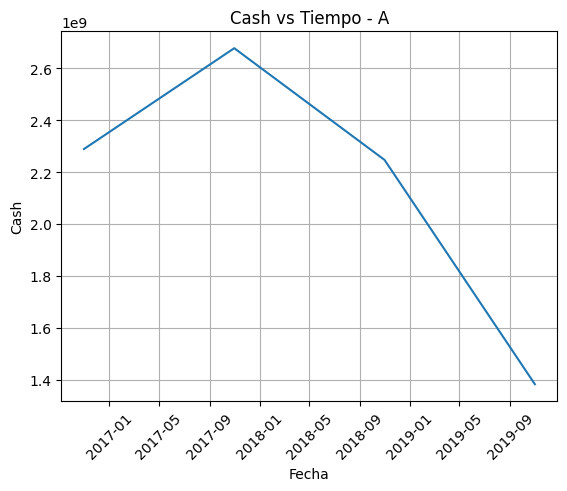

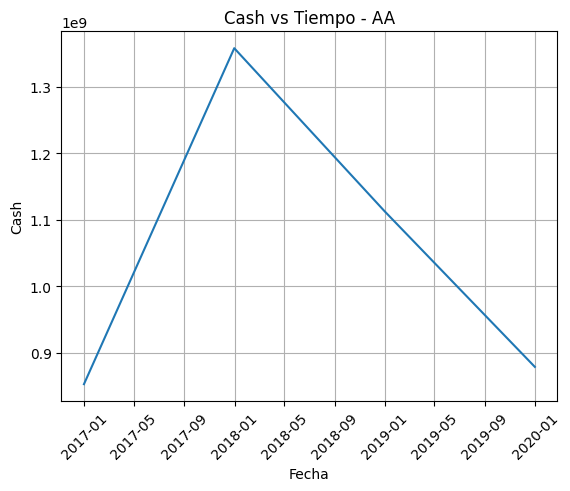

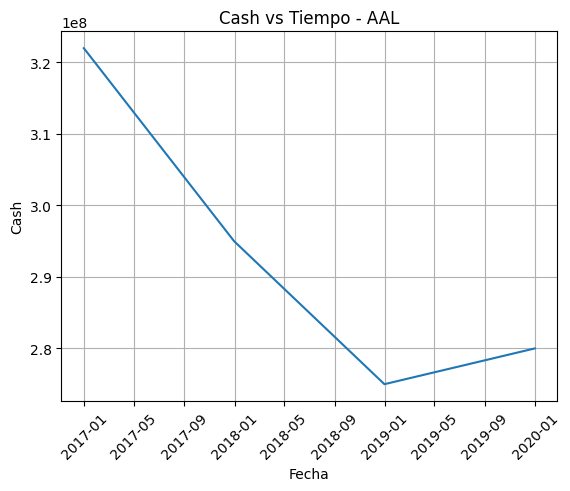

In [6]:
import matplotlib.pyplot as plt

empresas = [empresa1, empresa2, empresa3]

for empresa in empresas:

    plt.figure()

    plt.plot(empresa['endDate'], empresa['cash'])

    plt.title(f"Cash vs Tiempo - {empresa['stock'].iloc[0]}")
    plt.xlabel("Fecha")
    plt.ylabel("Cash")

    plt.xticks(rotation=45)
    plt.grid()

    plt.show()

In [7]:
def dividir_train_test(data):

    n = int(len(data) * 0.8)

    train = data.iloc[:n]
    test = data.iloc[n:]

    return train, test


train1, test1 = dividir_train_test(empresa1)
train2, test2 = dividir_train_test(empresa2)
train3, test3 = dividir_train_test(empresa3)

In [8]:
from sklearn.linear_model import LinearRegression
import numpy as np

def entrenar_modelo(train):

    train = train.copy()

    # crear variable temporal
    train['time'] = np.arange(len(train))

    X = train[['time']]
    y = train['cash']

    model = LinearRegression()
    model.fit(X, y)

    return model


model1 = entrenar_modelo(train1)
model2 = entrenar_modelo(train2)
model3 = entrenar_modelo(train3)

In [9]:
def predecir(model, train, test):

    test = test.copy()

    test['time'] = np.arange(len(train), len(train) + len(test))

    X_test = test[['time']]

    y_pred = model.predict(X_test)

    return y_pred


pred1 = predecir(model1, train1, test1)
pred2 = predecir(model2, train2, test2)
pred3 = predecir(model3, train3, test3)

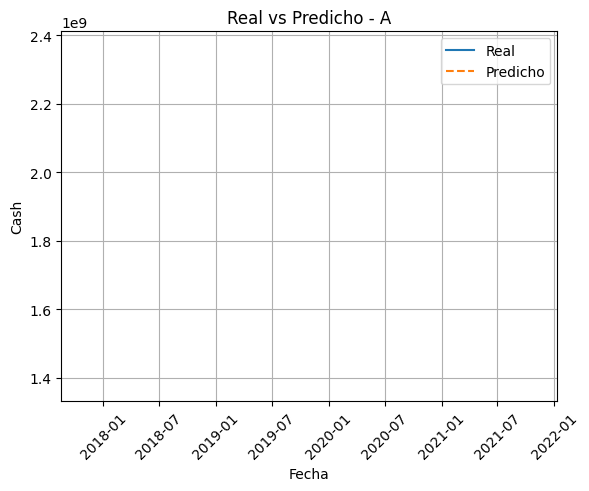

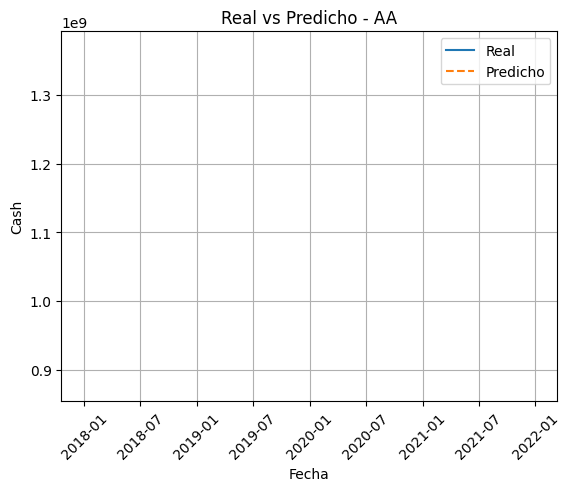

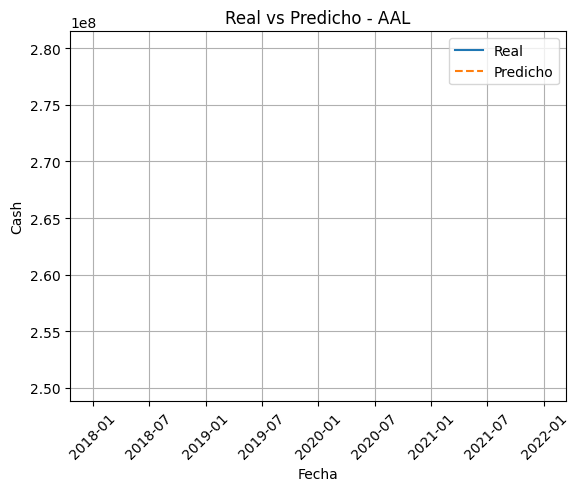

In [10]:
def graficar_real_vs_pred(test, pred, nombre):

    plt.figure()

    plt.plot(test['endDate'], test['cash'], label="Real")
    plt.plot(test['endDate'], pred, '--', label="Predicho")

    plt.title(f"Real vs Predicho - {nombre}")

    plt.xlabel("Fecha")
    plt.ylabel("Cash")

    plt.xticks(rotation=45)
    plt.legend()
    plt.grid()

    plt.show()


graficar_real_vs_pred(test1, pred1, stocks[0])
graficar_real_vs_pred(test2, pred2, stocks[1])
graficar_real_vs_pred(test3, pred3, stocks[2])

In [11]:
from sklearn.metrics import mean_squared_error, r2_score

def evaluar_modelo(test, pred):

    y_test = test['cash']

    mse = mean_squared_error(y_test, pred)
    rmse = np.sqrt(mse)
    r2 = r2_score(y_test, pred)

    return mse, rmse, r2


mse1, rmse1, r21 = evaluar_modelo(test1, pred1)
mse2, rmse2, r22 = evaluar_modelo(test2, pred2)
mse3, rmse3, r23 = evaluar_modelo(test3, pred3)


tabla_resultados = pd.DataFrame({

    "Empresa": [stocks[0], stocks[1], stocks[2]],
    "MSE": [mse1, mse2, mse3],
    "RMSE": [rmse1, rmse2, rmse3],
    "R2": [r21, r22, r23]

})

print(tabla_resultados)

  Empresa           MSE          RMSE  R2
0       A  9.617071e+17  9.806667e+08 NaN
1      AA  2.391210e+17  4.890000e+08 NaN
2     AAL  8.801111e+14  2.966667e+07 NaN


/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_regression.py:1266: UndefinedMetricWarning: R^2 score is not well-defined with less than two samples.
  warnings.warn(msg, UndefinedMetricWarning)
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_regression.py:1266: UndefinedMetricWarning: R^2 score is not well-defined with less than two samples.
  warnings.warn(msg, UndefinedMetricWarning)
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_regression.py:1266: UndefinedMetricWarning: R^2 score is not well-defined with less than two samples.
  warnings.warn(msg, UndefinedMetricWarning)


#Preguntas
#¿Qué variables (features) usaste para predecir cash y por qué crees que son relevantes?

En este modelo utilicé una variable temporal llamada time, que representa el orden de los registros a lo largo del tiempo. Esta variable permite que el modelo identifique la tendencia del efectivo de la empresa a medida que pasan los periodos financieros.

#¿Cómo realizaste la división temporal 80/20 por empresa y por qué es importante no barajar (shuffle) los datos en series temporales?

La división se realizó tomando el 80% de los primeros registros de cada empresa para el entrenamiento y el 20% final para la prueba. No se debe barajar los datos porque en las series temporales el orden del tiempo es importante y mezclar los datos podría hacer que el modelo utilice información del futuro para predecir el pasado.

#¿Cuál es la diferencia entre MSE y RMSE y qué nos dice cada métrica sobre la precisión de las predicciones?

El MSE mide el promedio de los errores al cuadrado entre los valores reales y los valores predichos por el modelo. El RMSE es la raíz cuadrada del MSE y tiene la misma unidad que la variable original, lo que hace que sea más fácil interpretar el error de predicción.

#¿Qué interpreta el valor de R² en este problema y qué limitaciones tiene en series temporales?

El valor de R² indica qué tan bien el modelo logra explicar la variación de la variable cash. Un valor cercano a 1 significa que el modelo explica bien los datos. Sin embargo, en series temporales puede no reflejar completamente el desempeño del modelo si existen patrones complejos o cambios en la tendencia a lo largo del tiempo.

#Si obtienes un RMSE alto o un R² bajo, ¿qué acciones propondrías para mejorar el modelo?

Si el error es alto o el R² es bajo, se podrían agregar más variables relevantes, como indicadores financieros adicionales o valores anteriores de cash. También se podrían usar modelos más avanzados como Random Forest o modelos especializados en series temporales.